In [14]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph.message import add_messages
from pprint import pprint
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from IPython.display import Image, display
from typing import Annotated
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.prebuilt import ToolNode, tools_condition

In [20]:
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "ReAct_Agent"

In [16]:
api_wrapper_arxiv = ArxivAPIWrapper(
    top_k_results=2,
    doc_content_chars_max=500
)

arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [17]:
result = arxiv.invoke("Attention is all you need")
print(result)

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi


In [18]:
api_wrapper_wiki = WikipediaAPIWrapper(
    top_k_results=2,
    doc_content_chars_max=500
)

wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [21]:
# Custom functions
def multiply(a:int, b: int) -> int:
    """Multiply a and b
    Args:
        a: first int
        b: second int
    """
    return a*b

def add(a:int, b: int) -> int:
    """Add a and b
    Args:
        a: first int
        b: second int
    """
    return a+b

def divide(a:int, b: int) -> float:
    """Divide a and b
    Args:
        a: first int
        b: second int
    """
    return a/b

def substract(a:int, b: int) -> int:
    """Substract a and b
    Args:
        a: first int
        b: second int
    """
    return a-b

In [23]:
tavily = TavilySearchResults()

C:\Users\Sohan\AppData\Local\Temp\ipykernel_2436\2290291758.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [24]:
tools = [arxiv, wiki, tavily, add, multiply, divide, substract]

In [ ]:
# Bind tools to LLM
llm = ChatGroq(model="llama-3.3-70b-versatile")
llm_with_tools = llm.bind_tools(tools)

In [27]:
llm_with_tools.invoke([HumanMessage(content="What is the recent AI new?")])

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'c0bwx9yfj', 'function': {'arguments': '{"query":"recent AI news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 888, 'total_tokens': 908, 'completion_time': 0.056271144, 'completion_tokens_details': None, 'prompt_time': 0.083112047, 'prompt_tokens_details': None, 'queue_time': 0.32153898, 'total_time': 0.139383191}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0258-ec2a-7490-98e2-c194496c13bd-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent AI news'}, 'id': 'c0bwx9yfj', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 888, 'output_tokens': 20, 'total_tokens': 908})

In [29]:
llm_with_tools.invoke([HumanMessage(content="What is the recent AI new?")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': '9wnf40kd3',
  'type': 'tool_call'}]

In [30]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

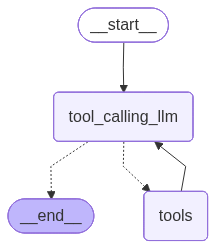

In [34]:
# Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm") # This is ReAct Agent Architecture

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [35]:
messages = graph.invoke({"messages": HumanMessage(content="Provide me top 5 recent AI news, then add 5 plus 5 and then multiply by 20.")})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Provide me top 5 recent AI news, then add 5 plus 5 and then multiply by 20.
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (kjdjb369v)
 Call ID: kjdjb369v
  Args:
    query: recent AI news
  add (sw51h9sxj)
 Call ID: sw51h9sxj
  Args:
    a: 5
    b: 5
  multiply (t8pxayz9m)
 Call ID: t8pxayz9m
  Args:
    a: 10
    b: 20
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News | Latest News | Insights Powering AI-Driven Business Growth", "url": "https://www.artificialintelligence-news.com", "content": "AI News is part of the TechForge Publications series\n\nTechForge\n\nAI in Action\n\n# The math behind the OpenAI Jalapeño chip\n\nJune 25, 2026\n\nSamsung opens ChatGPT Enterprise and Codex access after AI restrictions\n\nAI in Action\n\nJune 24, 2026\n\n

In [56]:
messages = graph.invoke({"messages": HumanMessage(content="Add 5 plus 5 and then divide by 2 and substract 3.")})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Add 5 plus 5 and then divide by 2 and substract 3.
================================== Ai Message ==================================
Tool Calls:
  add (8pnn5ejwv)
 Call ID: 8pnn5ejwv
  Args:
    a: 5
    b: 5
  divide (h85y5s3tb)
 Call ID: h85y5s3tb
  Args:
    a: 10
    b: 2
  substract (9kwc5wavr)
 Call ID: 9kwc5wavr
  Args:
    a: 5
    b: 3
================================= Tool Message =================================
Name: add

10
================================= Tool Message =================================
Name: divide

5.0
================================= Tool Message =================================
Name: substract

2
================================== Ai Message ==================================

The result of the operations is 2.
